In [10]:
#%conda install pytorch torchvision torchaudio pytorch-cuda=12.4 -c pytorch -c nvidia -y
#%conda install -c conda-forge gymnasium numpy pytesseract stable-baselines3 mss opencv matplotlib -y
#%conda install -c conda-forge pydirectinput -y

In [2]:
%pip install pynput

from pynput import mouse, keyboard

Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable



    opencv-python (>=3.) ; extra == 'all'
                  ~~~~^


In [3]:
import sqlite3

#mss used for screenshotting 
from mss import mss

#Gym used Environment components
import gymnasium as gym
from gymnasium import Env
from gymnasium import spaces

print("all good")

#Imports
#Pytorch used for the neural nets
import torch
import torchvision

#NumPy used for operations (Transformational framework)
import numpy as np

#OpenCV used for frame processing
import cv2

#Matplotlib to visualize captured frames
from matplotlib import pyplot as plt

#time for pauses
import time
from collections import deque



all good


In [4]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\envs\agent_env\python.exe


In [5]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("PyTorch CUDA Version:", torch.version.cuda)

CUDA Available: True
PyTorch CUDA Version: 12.1


In [6]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 4070 Laptop GPU


(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)
(80, 50)


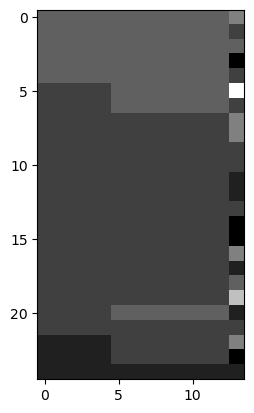

(25, 14)


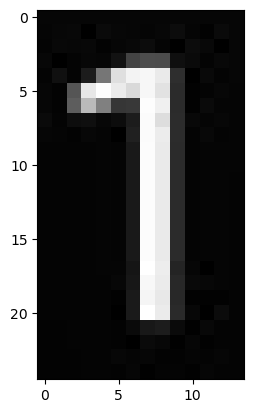

(25, 14)


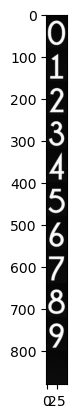

(880, 50)
(880, 52)


In [7]:
#preprocessing for stamps
stamp_paths = [
               r"C:\Osu!Conda\digits\one.jpg",
               r"C:\Osu!Conda\digits\two.jpg",
               r"C:\Osu!Conda\digits\three.jpg",
               r"C:\Osu!Conda\digits\four.jpg",
               r"C:\Osu!Conda\digits\five.jpg",
               r"C:\Osu!Conda\digits\six.jpg",
               r"C:\Osu!Conda\digits\seven.jpg",
               r"C:\Osu!Conda\digits\eight.jpg",
               r"C:\Osu!Conda\digits\nine.jpg",
               r"C:\Osu!Conda\digits\background.jpg"]

digit_stamps = ["dih"]
digit_stamps[0] = np.array((cv2.imread(r"C:\Osu!Conda\digits\zero.jpg", cv2.IMREAD_GRAYSCALE)))
for path in stamp_paths: 
    digit_stamps.append(np.array((cv2.imread(path, cv2.IMREAD_GRAYSCALE))))

start_row, end_row = 1000, 1080
start_col, end_col = 10, 60

digit_stamps[0] = digit_stamps[0][start_row:end_row, start_col+54:end_col+54]
print(digit_stamps[0].shape)


for x in range(1,11):
    digit_stamps[x] = digit_stamps[x][start_row:end_row, start_col:end_col]
    print(digit_stamps[x].shape)

'''for digit in range(0,11):
    plt.imshow(digit_stamps[digit], cmap='gray')
    time.sleep(0.5)
    plt.show()'''

percent_stamp_paths = [
               r"C:\Osu!Conda\percent_digits\first_digit_stamp\blank.jpg",
               r"C:\Osu!Conda\percent_digits\first_digit_stamp\one.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\two.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\three.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\four.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\five.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\six.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\seven.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\eight.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\nine.jpg",
               r"C:\Osu!Conda\percent_digits\second_digit_stamps\zero.jpg"]

percent_stamps = []

for path in percent_stamp_paths: 
    percent_stamps.append(np.array((cv2.imread(path, cv2.IMREAD_GRAYSCALE))))

start_row2, end_row2 = 55, 80
start_col2, end_col2 = 1812, 1826
offset=17

percent_stamps[0] = percent_stamps[0][start_row2:end_row2, start_col2-offset:end_col2-offset]
percent_stamps[1] = percent_stamps[1][start_row2:end_row2, start_col2-offset-8:end_col2-offset-8]

plt.imshow(percent_stamps[0], cmap='gray')
time.sleep(0.05)
plt.show()
print(percent_stamps[0].shape)

plt.imshow(percent_stamps[1], cmap='gray')
time.sleep(0.05)
plt.show()
print(percent_stamps[1].shape)

'''for x in range(2, 11):
    percent_stamps[x] = percent_stamps[x][start_row2:end_row2, start_col2:end_col2]
    print(percent_stamps[x].shape)'''

'''for percent in range(2,11):
    plt.imshow(percent_stamps[percent], cmap='gray')
    time.sleep(0.05)
    plt.show()'''

#stack all images for optimization
mega_template = np.vstack(digit_stamps[0:11]) 
plt.imshow(mega_template, cmap='gray')
time.sleep(0.05)
plt.show()
# Get the height of a single digit so we can math out the result later
h_digit = digit_stamps[0].shape[0]
print(mega_template.shape)

# 2. Add 2 pixels of width (1px left, 1px right) so it's wider than the live crop
# This changes width from 50 to 52
mega_template = cv2.copyMakeBorder(
    mega_template, 0, 0, 1, 1, cv2.BORDER_CONSTANT, value=0
)
print(mega_template.shape)

h_digit = digit_stamps[0].shape[0]

In [ ]:
#Screen Capture
def frame():
    with mss() as sct:
        osu_playfield = {"top": 0, "left": 240, "width": 1440, "height": 1080}

        # Get raw pixels from the screen, save it to a Numpy array, grayscale + resize
        raw_frame = sct.grab(osu_playfield)
        osu_frame_np = np.array(raw_frame)
        osu_frame_gray_np = cv2.cvtColor(osu_frame_np, cv2.COLOR_BGRA2GRAY)
        osu_frame_gray_resized_np = cv2.resize(
            osu_frame_gray_np,
            (84,84),
            interpolation = cv2.INTER_AREA
        )
        # returns 1,84,84
        return osu_frame_gray_resized_np[np.newaxis, :, :]
    
#function for screen capturing the 2 retry areas
def retry_frame():
    with mss() as sct:
        retry_screen1_area = {"top":500,"left":810,"width":300,"height":320}
        retry_screen2_area = {"top":790+30,"left":1560,"width":290,"height":170}
        # Get raw pixels from the screen, save it to a Numpy array
        r1 = sct.grab(retry_screen1_area)
        r2 = sct.grab(retry_screen2_area)
        r_1_np = np.array(r1)
        r_2_np = np.array(r2)
        #convert to grayscale + resize
        retry_1_box = cv2.cvtColor(r_1_np, cv2.COLOR_BGR2GRAY)
        retry_2_box = cv2.cvtColor(r_2_np, cv2.COLOR_BGR2GRAY)

        retry_bounds = (retry_1_box,retry_2_box)
        return retry_bounds
    
#returns a tuple of the 4 combo digit areas
def digit_frames():
    with mss() as sct:
        digit_screen1_area = {"top":start_row,"left":start_col,"width":50,"height":80}
        digit_screen2_area = {"top":start_row,"left":start_col+55,"width":50,"height":80}
        digit_screen3_area = {"top":start_row,"left":start_col+110,"width":50,"height":80}
        digit_screen4_area = {"top":start_row,"left":start_col+165,"width":50,"height":80}

        # Get raw pixels from the screen, save it to a Numpy array
        r1 = sct.grab(digit_screen1_area)
        r2 = sct.grab(digit_screen2_area)
        r3 = sct.grab(digit_screen3_area)
        r4 = sct.grab(digit_screen4_area)

        r_1_np = np.array(r1)
        r_2_np = np.array(r2)
        r_3_np = np.array(r3)
        r_4_np = np.array(r4)
        #convert to grayscale + resize
        digits_box_1 = cv2.cvtColor(r_1_np, cv2.COLOR_BGR2GRAY)
        digits_box_2 = cv2.cvtColor(r_2_np, cv2.COLOR_BGR2GRAY)
        digits_box_3 = cv2.cvtColor(r_3_np, cv2.COLOR_BGR2GRAY)
        digits_box_4 = cv2.cvtColor(r_4_np, cv2.COLOR_BGR2GRAY)

        retry_bounds = (digits_box_1,digits_box_2,digits_box_3,digits_box_4)
        return retry_bounds
    


top = 55
left = 1810-3
width = 14
height = 25
off_set = 16
def percent_frames():
    with mss() as sct:
        digit_screen1_area = {"top":top,"left":left,"width":width,"height":height}
        digit_screen2_area = {"top":top,"left":left+off_set,"width":width,"height":height}
        digit_screen3_area = {"top":top,"left":left+off_set*2-1,"width":width,"height":height}
        digit_screen4_area = {"top":top,"left":left+off_set*3+6,"width":width,"height":height}
        digit_screen5_area = {"top":top,"left":left+off_set*4+4,"width":width,"height":height}

        # Get raw pixels from the screen, save it to a Numpy array
        r1 = sct.grab(digit_screen1_area)
        r2 = sct.grab(digit_screen2_area)
        r3 = sct.grab(digit_screen3_area)
        r4 = sct.grab(digit_screen4_area)
        r5 = sct.grab(digit_screen5_area)

        r_1_np = np.array(r1)
        r_2_np = np.array(r2)
        r_3_np = np.array(r3)
        r_4_np = np.array(r4)
        r_5_np = np.array(r5)

        #convert to grayscale + resize
        digits_box_1 = cv2.cvtColor(r_1_np, cv2.COLOR_BGR2GRAY)
        digits_box_2 = cv2.cvtColor(r_2_np, cv2.COLOR_BGR2GRAY)
        digits_box_3 = cv2.cvtColor(r_3_np, cv2.COLOR_BGR2GRAY)
        digits_box_4 = cv2.cvtColor(r_4_np, cv2.COLOR_BGR2GRAY)
        digits_box_5 = cv2.cvtColor(r_5_np, cv2.COLOR_BGR2GRAY)

        percent_bounds = (digits_box_1,digits_box_2,digits_box_3,digits_box_4,digits_box_5)
        return percent_bounds

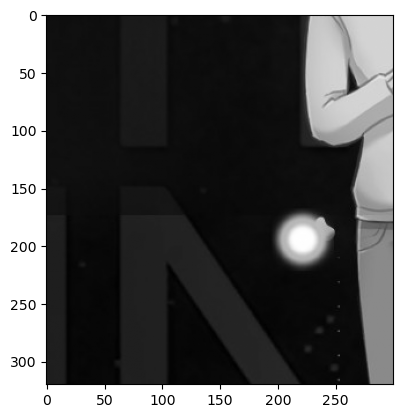

In [ ]:
time.sleep(2)
retry_1, retry_2 = retry_frame()
plt.imshow(retry_1, cmap='gray')
plt.show()

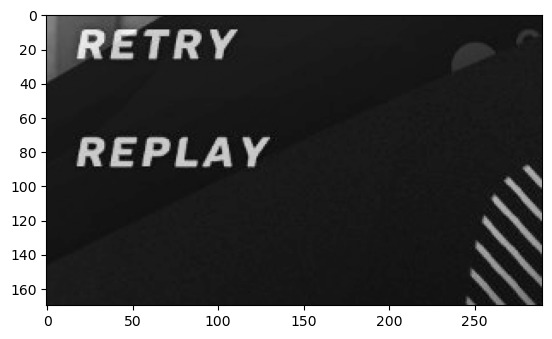

In [76]:
plt.imshow(retry_2, cmap='gray')
plt.show()


In [10]:
digit1, _, _, _ = digit_frames()
_, d2, _, _ = digit_frames()
print(digit1.shape)
print(d2.shape)

(80, 50)
(80, 50)


In [15]:
from pynput.mouse import Controller as MouseController, Button
from pynput.keyboard import Controller as KeyboardController

In [16]:
# =========================
# CONSTANTS 
# =========================
BACKGROUND_INDEX = 10
MIN_ACCEPT_SCORE = 0.75
MAX_FORWARD_JUMP = 12
MIN_MARGIN = 0.08

# Break handling
BREAK_LANDS_AT_OR_BELOW = 1
BREAK_CONFIRM_FRAMES = 2
BREAK_STRICT_CONF = 0.80

# Transition handling
ROLLOVER_TOLERANCE = 3
ROLLOVER_MAX_OVERSHOOT = 15

# NEW: anti-stuck / history + latch
HIST_LEN = 6
BREAK_LATCH_MS = 200               # Allow backwards updates briefly after break
BIG_DROP_RATIO = 0.6               # If RAW < 60% of STABLE, it's a break
BIG_DROP_MIN = 8                   # Or if RAW is 8 digits lower than STABLE
ALLOW_BACKWARDS_DURING_LATCH = True
APPEND_ZERO_REJECT = True          # Reject stable->stable*10 (9->90)
APPEND_ZERO_CONF_MIN = 0.75 
ACCURACY_CONFIDENCE_THRESHOLD = 0.6



In [17]:
#Math Helpers for the Combo detector

def num_digits(n: int) -> int:
    return 1 if n == 0 else len(str(n))

def expected_rollover(prev: int) -> int:
    d = num_digits(prev)
    return 10 ** d

def is_plausible_rollover(prev: int, raw: int) -> bool:
    exp = expected_rollover(prev)
    if exp <= raw <= exp + ROLLOVER_TOLERANCE:
        return True
    if exp <= raw <= exp + ROLLOVER_MAX_OVERSHOOT:
        return True
    return False

In [18]:
class OsuScreenEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.mega_digit_template = mega_template
        self.digit_h = h_digit

        # =========================
        # SETTINGS 
        # =========================
       
        self.last_good_combo = 0
        self.break_streak = 0
        self.raw_hist = []                      # List of tuples (raw, conf)
        self.break_latch_until = 0.0

        self.last_stable_val= 100.0
        self.waiting_val = None
        self.total_frames_processed = 0

        
        self.dead = False
        self.stamp_1_path = r"C:\Osu!Conda\images\Retry Screen 1 - Stamp.jpg"
        self.stamp_1 = cv2.imread(self.stamp_1_path)
        self.stamp_gray_1 = cv2.cvtColor(self.stamp_1, cv2.COLOR_BGR2GRAY)

        self.stamp_2_path = r"C:\Osu!Conda\images\Retry Screen 2 - Stamp.jpg"
        self.stamp_2 = cv2.imread(self.stamp_2_path)
        self.stamp_gray_2 = cv2.cvtColor(self.stamp_2, cv2.COLOR_BGR2GRAY)

        #testing max steps so my computer doesnt die
        self.max_steps = 1000   
        self.step_count = 0
        self.is_holding = False

        # Controllers
        self.mouse = MouseController()
        self.keyboard = KeyboardController()

        # Frame stacking
        self.stack = 4
        self.frames = deque(maxlen=self.stack)

        # Timing
        self.prev_t = None

        # Image size
        self.h = 84
        self.w = 84

        # Scalar observation size
        self.scalar_info_dimensions = 4

        # Observation space
        self.observation_space = spaces.Dict({
            "vision": spaces.Box(
                low=0,
                high=255,
                shape=(self.stack, self.h, self.w),
                dtype=np.uint8
            ),
            "stats": spaces.Box(
                low=-1.0,
                high=1.0,
                shape=(self.scalar_info_dimensions,),
                dtype=np.float32
            )
        })

        # Action space: dx, dx, click, release
        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0, 0.0], dtype=np.float32),
            high=np.array([1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        # Cursor state
        self.cursor_current_xy = np.array([0.0, 0.0])
        self.prev_cursor_xy = np.array([0.0, 0.0])
        self.vxy = np.array([0.0, 0.0])

    # Core Gym Methods

    def step(self, action):

        if self.dead:
            terminated = True
            truncated = False
            reward = 0.0
            obs = {
                "vision": np.stack(list(self.frames), axis=0).astype(np.uint8),
                "stats": self.build_stats()
            }
            info = {"dead": True}
            return obs, reward, terminated, truncated, info
        
        old_combo = self.last_good_combo
        old_acc   = self.last_stable_val

        #testing step counter so my computer doesnt die 
        self.step_count += 1
        truncated = self.step_count >= self.max_steps
        # timing
        now = time.time()
        dt = 0.0416 if self.prev_t is None else max(1e-4, now - self.prev_t)
        self.prev_t = now
        self.apply_action(action)

        self.update_cursor_state(dt)

        # capture frame
        frame_1chw = self.capture_frame()
        frame_hw = frame_1chw[0]

        #read the combo and accuracy frames
        current_combo = self.read_combo_once()
        current_acc   = self.read_accuracy_once(old_acc)

        #padding for the first frame
        self.frames.append(frame_hw)
        while len(self.frames) < self.stack:
            self.frames.append(frame_hw)
        stacked_vision = np.stack(self.frames, axis=0).astype(np.uint8)

        if truncated:
            terminated = False
            reward = 0.0
            obs = {
                "vision": stacked_vision,
                "stats": self.build_stats()
            }
            info = {"truncated": True}
            return obs, reward, terminated, truncated, info

        # observation, reward
        obs = {
            "vision": stacked_vision,
            "stats": self.build_stats()
        }
        reward = self.compute_reward(old_combo, current_combo, old_acc, current_acc)

        #death detection each step
        retry_frames_step = self.detect_death()
        if retry_frames_step["retry_screen_1"] == True or retry_frames_step["retry_screen_2"] == True:
            self.dead = True
            terminated = True
        else: 
            terminated = False

        

        info = {
            "combo": current_combo,
            "acc": current_acc,
            "reward": reward,
            "step": self.step_count,
            "is_holding": self.is_holding,
            "delta_combo": current_combo - old_combo,
            "delta_acc": round(current_acc - old_acc, 4)}

        return obs, reward, terminated, truncated, info



    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.mega_digit_template = mega_template
        
        self.digit_h = h_digit


        self.waiting_val = None
        self.step_count = 0
        self.dead = False
        self.last_good_combo = 0
        self.last_stable_val = 100.0   # Reset accuracy filter
        self.total_frames_processed = 0 # Reset accuracy filter
        self.raw_hist.clear()           # Clear combo history
        self.break_latch_until = 0.0
        self.is_holding = False
        try:
            self.mouse.release(Button.left)  # safety release in case last run got stuck holding
        except Exception:
            pass

    
        # reset timing
        self.prev_t = time.time()

        # random cursor start
        x = np.random.randint(240, 240 + 1440)
        y = np.random.randint(0, 1080)
        self.mouse.position = (x, y)

        start_rel = np.array([x - 240, y], dtype=np.float32)
        self.prev_cursor_xy = start_rel
        self.cursor_current_xy = start_rel / np.array([1440.0, 1080.0])
        self.vxy = np.array([0.0, 0.0])

        # initialize frame stack
        self.frames.clear()
        frame_1chw = self.capture_frame()
        frame_hw = frame_1chw[0]
        for _ in range(self.stack):
            self.frames.append(frame_hw)

        obs = {
            "vision": np.stack(self.frames, axis=0).astype(np.uint8),
            "stats": self.build_stats()
        }

        return obs, {}
    
    # Helpers

    def read_accuracy_once(self, previous_accuracy_value):
        
        """
        Reads the 5-digit accuracy display, converts it to a float, 
        and waits for the value to 'settle' to filter out UI animations.
        """
        
        # 1. Capture and match digits
        digit_box_crops = percent_frames() 
        detected_digits = []
        match_confidences = []

        for i, crop in enumerate(digit_box_crops):
            best_match_index = -1
            highest_similarity_score = -1.0
            
            for stamp_index, stamp_image in enumerate(percent_stamps):
                result_map = cv2.matchTemplate(crop, stamp_image, cv2.TM_CCOEFF_NORMED)
                _, max_similarity, _, _ = cv2.minMaxLoc(result_map)
                
                if max_similarity > highest_similarity_score:
                    highest_similarity_score = max_similarity
                    best_match_index = stamp_index
            
            if best_match_index == 0: 
                detected_digits.append(None)
            elif best_match_index == 10: 
                detected_digits.append(0)
            else: 
                detected_digits.append(best_match_index)
            match_confidences.append(highest_similarity_score)

        # 2. Position-based math
        try:
            hundreds_val   = detected_digits[0] if detected_digits[0] is not None else 0
            tens_val       = detected_digits[1] if detected_digits[1] is not None else 0
            ones_val       = detected_digits[2] if detected_digits[2] is not None else 0
            tenths_val     = detected_digits[3] if detected_digits[3] is not None else 0
            hundredths_val = detected_digits[4] if detected_digits[4] is not None else 0
            
            calculated_accuracy = (
                (hundreds_val * 100) + (tens_val * 10) + (ones_val * 1) + 
                (tenths_val * 0.1) + (hundredths_val * 0.01)
            )
            average_match_confidence = sum(match_confidences) / 5
            print(average_match_confidence)
        except Exception as error:
            print(f"Error calculating accuracy: {error}")
            return previous_accuracy_value

        # --- SAFETY & SETTLING FILTERS ---
        
        # Filter 1: Confidence
        if average_match_confidence < ACCURACY_CONFIDENCE_THRESHOLD:
            return previous_accuracy_value 

        # Filter 2: Max Value
        if calculated_accuracy > 100.0:
            calculated_accuracy = 100.0

        

        self.total_frames_processed += 1

        # 1. Calculate Dynamic Leeway
        if self.total_frames_processed < 500:
            trust_threshold = 70.0  # Massive leeway for early game nuance
        else:
            # Gradually tightens: e.g., ~31% at frame 2500, ~22% at frame 5000
            trust_threshold = 100.0 * (250 / self.total_frames_processed)**1.4

        # 2. Flicker Gate Logic
        diff = abs(calculated_accuracy - self.last_stable_val)

        if diff > trust_threshold:
            if self.waiting_val is not None and abs(calculated_accuracy - self.waiting_val) < 0.05:
                # This is the 2nd frame in a row showing this big change.
                # It's not a flicker, it's real nuance! Update now.
                self.last_stable_val = calculated_accuracy
                self.waiting_val = None
            else:
                # Possible flicker detected. Put in waiting room, return old value.
                self.waiting_val = calculated_accuracy
                return previous_accuracy_value
        else:
            # Small change, update normally
            self.last_stable_val = calculated_accuracy
            self.waiting_val = None

        return self.last_stable_val
    





    def read_combo_once(self):
        # 1. Capture and Match Digits
        digits = digit_frames() 
        recognized_digits = []
        digit_scores = []

        for x in range(4):
            # ONE call replaces the 'for y in range(11)' loop
            res = cv2.matchTemplate(self.mega_digit_template, digits[x], cv2.TM_CCOEFF_NORMED)            
            # We need the two best matches to calculate 'match_margin'
            # To get the 2nd best, we'd need more math, but usually, 
            # a high max_val is enough for osu! digits. 
            # Let's stick to your margin logic by simplifying it:
            _, max_val, _, max_loc = cv2.minMaxLoc(res)
            
            # Math: Which digit in the stack did we hit?
            best_match_index = max_loc[1] // self.digit_h
            best_match_score = float(max_val)

            # Break if it hits background or low confidence 
            if best_match_index == BACKGROUND_INDEX:
                break
                
            recognized_digits.append(best_match_index)
            digit_scores.append(best_match_score)

        # 2. Build Raw Value
        if not recognized_digits:
            raw_combo = 0
            confidence = 0.0
        else:
            raw_combo = int("".join(str(d) for d in recognized_digits))
            confidence = float(min(digit_scores))

        if len(recognized_digits) >= 2 and all(d == 0 for d in recognized_digits):
            confidence = 0.0

        # Push to the instance history for break detection
        self._push_hist(raw_combo, confidence)

        # 3. Filter into Stable Combo
        stable_combo = self.last_good_combo
        accepted = False
        now = time.time()
        in_latch = now < self.break_latch_until

        if confidence >= MIN_ACCEPT_SCORE:
            # A. Appended Zero Reject (e.g., 9 -> 90)
            if (APPEND_ZERO_REJECT and confidence >= APPEND_ZERO_CONF_MIN and 
                self.last_good_combo >= 1 and raw_combo == self.last_good_combo * 10):
                pass # Rejected
            
            # B. Same Value
            elif raw_combo == self.last_good_combo:
                accepted = True
            
            # C. Forward Movement
            elif raw_combo > self.last_good_combo:
                jump = raw_combo - self.last_good_combo
                if jump <= MAX_FORWARD_JUMP:
                    stable_combo = raw_combo
                    accepted = True
                elif is_plausible_rollover(self.last_good_combo, raw_combo):
                    stable_combo = raw_combo
                    accepted = True

            # D. Backwards Movement (Breaks)
            else:
                if ALLOW_BACKWARDS_DURING_LATCH and in_latch:
                    stable_combo = raw_combo
                    accepted = True
                else:
                    tiny_cnt, bigdrop_cnt = self._count_break_like(self.last_good_combo)
                    # Use  constants for confirmation frames
                    break_confirmed = (tiny_cnt >= BREAK_CONFIRM_FRAMES) or (bigdrop_cnt >= BREAK_CONFIRM_FRAMES)

                    if break_confirmed:
                        stable_combo = raw_combo
                        accepted = True
                        self.break_latch_until = now + (BREAK_LATCH_MS / 1000.0)
                    elif (raw_combo <= BREAK_LANDS_AT_OR_BELOW and 
                          self.last_good_combo > BREAK_LANDS_AT_OR_BELOW and 
                          confidence >= 0.95):
                        stable_combo = raw_combo
                        accepted = True
                        self.break_latch_until = now + (BREAK_LATCH_MS / 1000.0)

        if accepted:
            self.last_good_combo = stable_combo

        return self.last_good_combo



    def apply_action(self, action):
        dx, dy, hold = action

        max_pixels = 350
        self.mouse.move(int(dx * max_pixels), int(dy * max_pixels))

        want_hold = (hold > 0.5)
    # State-based press/release so we don't spam press() every frame
        if want_hold and not self.is_holding:
            self.mouse.press(Button.left)
            self.is_holding = True
        elif (not want_hold) and self.is_holding:
            self.mouse.release(Button.left)
            self.is_holding = False

    def _push_hist(self, raw, conf):
        # Notice we use self.raw_hist now
        self.raw_hist.append((raw, conf))
        if len(self.raw_hist) > HIST_LEN:
            self.raw_hist.pop(0)

    def _count_break_like(self, stable_now: int):
        tiny = 0
        bigdrop = 0
        # Iterate through the history stored in this specific instance
        for r, c in self.raw_hist:
            if c >= BREAK_STRICT_CONF:
                if r <= BREAK_LANDS_AT_OR_BELOW:
                    tiny += 1
                
                if stable_now > r:
                    is_significant = (
                        (stable_now - r >= BIG_DROP_MIN) or 
                        (r <= stable_now * BIG_DROP_RATIO) or
                        (stable_now < 10 and r < stable_now)
                    )
                    if is_significant:
                        bigdrop += 1
        return tiny, bigdrop

    def capture_frame(self):
        return frame()

    def update_cursor_state(self, dt):
        abs_x, abs_y = self.mouse.position
        rel_xy = np.array([abs_x - 240, abs_y], dtype=np.float32)

        raw_v = (rel_xy - self.prev_cursor_xy) / dt
        self.vxy = np.clip(raw_v / 12000.0, -1.0, 1.0)
        self.cursor_current_xy = rel_xy / np.array([1440.0, 1080.0])
        self.prev_cursor_xy = rel_xy

    def build_stats(self):
        return np.array([
            self.cursor_current_xy[0],
            self.cursor_current_xy[1],
            self.vxy[0],
            self.vxy[1]
        ], dtype=np.float32)

    def compute_reward(self, old_combo, current_combo, old_acc, current_acc):

        
        reward = 0.0
    
        # 1. Combo Increase (Success!)
        if current_combo > old_combo:
            reward += 1.0 + round(current_combo**(1/4), 2)
        
        # 2. Combo Decrease (The obvious break)
        elif current_combo < old_combo:
            reward -= 5.0
            
        # 3. The "Hidden" Miss (0 to 0 combo, but acc dropped)
        elif current_combo == 0 and current_acc < old_acc:
            reward -= 1 # Smaller penalty than a full combo break
            
        return reward


    def hit_retry(self):
        r = self.detect_death()
        while r["retry_screen_1"] == True or r["retry_screen_2"] == True:
            if r["retry_screen_1"] == True:
                self.mouse.position = (1920/2,1080/2+20)
                self.mouse.press(Button.left)
                self.mouse.release(Button.left)
            elif r["retry_screen_2"] == True:
                self.mouse.position = (1600,810)
                self.mouse.press(Button.left)
                self.mouse.release(Button.left)
            r = self.detect_death()
            
        
    def close(self):
        cv2.destroyAllWindows()

    def retry_frames(self):
        return retry_frame()


    def detect_death(self):
        self.retry_1_frame, self.retry_2_frame = self.retry_frames()
        detected_retry = {"retry_screen_1": False,
                          "retry_screen_2": False}

        similarity_map_1 = cv2.matchTemplate(self.retry_1_frame, self.stamp_gray_1, cv2.TM_CCOEFF_NORMED)
        _, max_val_1, _, _ = cv2.minMaxLoc(similarity_map_1)

        similarity_map_2 = cv2.matchTemplate(self.retry_2_frame, self.stamp_gray_2, cv2.TM_CCOEFF_NORMED)
        _, max_val_2, _, _ = cv2.minMaxLoc(similarity_map_2)

        if max_val_1 > 0.4:
            detected_retry["retry_screen_1"] = True
            return detected_retry

        elif max_val_2 > 0.4:
            detected_retry["retry_screen_2"] = True
            return detected_retry
        return detected_retry

    
        

In [ ]:
#percent testing in game: 
import time
last_stable_val = 100.0  # Start at 100%
waiting_val = None
total_frames_processed = 0
# --- INITIAL STATE ---
# We start at 100.0 because that is how every song begins
current_accuracy = 100.0
frame_count = 0

print("--- ACCURACY OCR TEST STARTING ---")
print("Switch to the game window now! Testing starts in 5 seconds...")
time.sleep(5)

try:
    while True:
        start_time = time.perf_counter()
        
        # 1. Capture the frame and calculate the new accuracy
        # We pass 'current_accuracy' so the function can compare the new read to the old one
        new_read = read_accuracy_once(current_accuracy)
        
        # 2. Update our tracker
        current_accuracy = new_read
        frame_count += 1
        
        # 3. Print the debug line
        # Every 3 frames (~20 times a second) to avoid spamming the console too hard
        if frame_count % 3 == 0:
            print(f"FRAME: {frame_count:05d} | ACCURACY: {current_accuracy:6.2f}%")

        # 4. Maintain timing
        # Aiming for ~60Hz (0.016s). We subtract the time the OCR took to keep it steady.
        elapsed = time.perf_counter() - start_time
        sleep_time = max(0, 0.016 - elapsed)
        time.sleep(sleep_time)

except KeyboardInterrupt:
    print("\n--- TEST TERMINATED BY USER ---")
    print(f"Final Accuracy Recorded: {current_accuracy}%")

In [19]:
env = OsuScreenEnv()
obs, info = env.reset()
print(type(obs), obs.keys())
print(obs["vision"].shape, obs["vision"].dtype)
print(obs["stats"].shape, obs["stats"].dtype)


<class 'dict'> dict_keys(['vision', 'stats'])
(4, 84, 84) uint8
(4,) float32


In [22]:

'''from pynput import mouse
from pynput.mouse import Button, Controller

mouse = Controller()
for i in range (500000):
    cursor_current_x,cursor_current_y = mouse.position
    print(cursor_current_x)
    print(cursor_current_y)
'''

'from pynput import mouse\nfrom pynput.mouse import Button, Controller\n\nmouse = Controller()\nfor i in range (500000):\n    cursor_current_x,cursor_current_y = mouse.position\n    print(cursor_current_x)\n    print(cursor_current_y)\n'

In [23]:


def kill_switch(key):
    if key == keyboard.Key.space:
        print("KILL SWITCH PRESSED")
        sys.exit(0)

listener = keyboard.Listener(on_press=kill_switch)
listener.start()


In [122]:
TARGET_FPS = 24
FRAME_TIME = 1.0 / TARGET_FPS
NUM_EPISODES = 3
print("Starting... Switch to osu!")
time.sleep(10)

for episode in range(NUM_EPISODES):
    obs, _ = env.reset()
    done = False
    
    while not done:
        loop_start = time.time() # Record the exact start time

        # 1. Run the action and environment logic
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        
        # 2. Monitor for exit
        done = terminated or truncated

        # 3. ENFORCE TIMING
        loop_end = time.time()
        elapsed = loop_end - loop_start
        sleep_time = FRAME_TIME - elapsed
        
        if sleep_time > 0:
            time.sleep(sleep_time)
        else:
            # If this prints often, your OCR is too slow for 24 FPS!
            print(f"Warning: Loop lag! Over by {abs(sleep_time):.4f}s")

    print(f"Episode {episode+1} finished.")

Starting... Switch to osu!
0.9993521213531494
0.9993521213531494
0.9993521213531494
0.9993521213531494
0.9993521213531494
0.9993521213531494
0.9993521213531494
0.9993521213531494
0.9993521213531494
0.9993521213531494
0.9993521213531494
0.9977602005004883
0.9977301836013794
0.9990215063095093
0.9989704966545105
0.9942167282104493
0.9914054870605469
Episode 1 finished.
0.9905353665351868
Episode 2 finished.
0.9905353665351868
Episode 3 finished.


In [25]:
#model architecture